In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

project_path = "/content/drive/MyDrive/PD_Project"
os.makedirs(project_path, exist_ok=True)
print("Project folder ready")


Project folder ready


In [3]:
import numpy as np
import random
import tensorflow as tf
import os

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import pandas as pd


In [4]:
!rm -rf CSV physionet.org

In [5]:
!ls

drive  sample_data


In [6]:
!file gait-in-parkinsons-disease-1.0.0.zip


gait-in-parkinsons-disease-1.0.0.zip: cannot open `gait-in-parkinsons-disease-1.0.0.zip' (No such file or directory)


In [7]:
!wget -r -N -c -np https://physionet.org/files/gaitpdb/1.0.0/


--2026-05-02 15:06:09--  https://physionet.org/files/gaitpdb/1.0.0/
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/gaitpdb/1.0.0/index.html’

physionet.org/files     [ <=>                ]  36.17K  --.-KB/s    in 0.08s   

Last-modified header missing -- time-stamps turned off.
2026-05-02 15:06:09 (466 KB/s) - ‘physionet.org/files/gaitpdb/1.0.0/index.html’ saved [37042]

Loading robots.txt; please ignore errors.
--2026-05-02 15:06:09--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 22 [text/plain]
Saving to: ‘physionet.org/robots.txt’

physionet.org/robot 100%[===================>]      22  --.-KB/s    in 0s      

2026-05-02 15:06:09 (12.0 MB/s) - ‘physionet.org/robots.txt’ saved [22/22]

--2026-05-02 

In [8]:
input_dir = '/content/physionet.org/files/gaitpdb/1.0.0'
len(os.listdir(input_dir))

313

In [9]:
features = ['Time', 'L1' , 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'Total_Force_Left', 'Total_Force_Right']

In [10]:
!mkdir CSV

In [11]:
i = 0
for file in os.listdir(input_dir):
    i = i+1
    ##print(i)
    if file[0:2]=='Ga' or file[0:2]=='Ju' or file[0:2] == 'Si':
        pass
        ##print(file)
        df = pd.read_csv(input_dir + '/' + file, header = None, sep = '\t', on_bad_lines = 'skip')

        df.columns = features

        name = 'CSV/' + file.split('.')[0] + '.csv'
        df.to_csv(name, index = None)

print(i)

313


In [12]:
demographics = pd.read_csv(input_dir + '/demographics.txt', delim_whitespace = True)
sub_id = demographics.ID.to_list()
sub_names = []
for name in os.listdir('CSV'):
    sub_name = name.split('_')[0]
    sub_names.append(sub_name)

print("Subjects Count = ", len(sub_id))
print("Files Count = ", len(sub_names))

Subjects Count =  166
Files Count =  306


/tmp/ipykernel_2076/1169665948.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  demographics = pd.read_csv(input_dir + '/demographics.txt', delim_whitespace = True)


In [13]:
!mkdir train
!mkdir validate
!mkdir test

In [14]:
count = len(os.listdir('CSV'))
train_count = int(70/100*count)
valid_count = int(15/100*count)
test_count = count - train_count - valid_count

print("Training count = ", train_count)
print("Validate count = ", valid_count)
print("Test count = ", test_count)

Training count =  214
Validate count =  45
Test count =  47


In [15]:
def load():
    count = len(os.listdir('CSV'))
    train_count = int(70/100*count)
    valid_count = int(15/100*count)
    test_count = count - train_count - valid_count

    train_X = list()
    train_Y = list()

    valid_X = list()
    valid_Y = list()

    test_X = list()
    test_Y = list()

    i = 0

    file_list = os.listdir('CSV')
    random.shuffle(file_list)
    for name in file_list:
        ##if(i>10):
        ##    break
        ##print(name)
        sub_id = name.split('_')[0]
        sub_class = demographics[demographics['ID']==sub_id]['Group']
        sub_class -= 1
        sub_class.to_string(index=False).strip()
        ##(sub_class)

        dataframe = pd.read_csv('CSV/' + name)
        full_size = 400
        skip = 50

        X = list()

        max_j = 150
        for j in range(0, dataframe.shape[0], skip):
            if dataframe.shape[0]>=full_size+j:
                temp = list()
                for feature in features:
                    temp.append(dataframe.iloc[j:j+full_size, ][feature].to_numpy())
                ##X.append(temp)
            if(i<train_count):
                train_X.append(temp)
                train_Y.append(sub_class)
                        ##print(i, name, "train")
            elif(train_count<=i<valid_count+train_count):
                valid_X.append(temp)
                valid_Y.append(sub_class)
                        ##print(i, name, "valid")
            else:
                test_X.append(temp)
                test_Y.append(sub_class)
                    ##print(i, name, "test")
        print(i, name)
        i+=1

    train_X = np.array(train_X)
    train_Y = tf.keras.utils.to_categorical(train_Y)

    valid_X = np.array(valid_X)
    valid_Y = tf.keras.utils.to_categorical(valid_Y)

    test_X = np.array(test_X)
    test_Y = tf.keras.utils.to_categorical(test_Y)


    return train_X, train_Y, valid_X, valid_Y, test_X, test_Y

In [16]:
train_X, train_Y, valid_X, valid_Y, test_X, test_Y = load()
print("Training Data = ", train_X.shape)
print("Training Class = ", train_Y.shape)
print("Valid Data = ", valid_X.shape)
print("Valid Class = ", valid_Y.shape)
print("Test Data = ", test_X.shape)
print("Test Class = ", test_Y.shape)

0 GaPt22_10.csv
1 JuPt15_05.csv
2 GaPt16_02.csv
3 JuPt20_07.csv
4 GaCo09_02.csv
5 JuCo04_01.csv
6 JuCo18_01.csv
7 SiCo27_01.csv
8 SiPt13_01.csv
9 SiPt21_01.csv
10 JuPt29_04.csv
11 GaPt33_01.csv
12 JuPt16_01.csv
13 SiCo25_01.csv
14 SiCo10_01.csv
15 GaPt31_01.csv
16 GaPt07_01.csv
17 GaPt28_10.csv
18 GaPt20_02.csv
19 JuPt20_04.csv
20 GaCo13_02.csv
21 GaPt06_01.csv
22 GaCo08_01.csv
23 JuPt23_04.csv
24 GaCo01_01.csv
25 JuCo07_01.csv
26 JuPt29_02.csv
27 JuCo01_01.csv
28 SiCo15_01.csv
29 JuPt17_01.csv
30 SiCo05_01.csv
31 GaCo17_01.csv
32 SiPt22_01.csv
33 GaPt32_02.csv
34 SiPt25_01.csv
35 JuPt28_02.csv
36 JuPt01_02.csv
37 GaPt08_02.csv
38 JuCo05_01.csv
39 GaCo15_01.csv
40 JuCo13_01.csv
41 JuPt03_04.csv
42 GaPt31_02.csv
43 GaPt26_02.csv
44 JuCo21_01.csv
45 SiPt30_01.csv
46 GaPt29_10.csv
47 GaPt29_01.csv
48 GaCo06_02.csv
49 SiPt17_01.csv
50 JuPt28_01.csv
51 JuPt06_07.csv
52 GaPt27_01.csv
53 GaCo05_02.csv
54 SiCo12_01.csv
55 JuPt01_01.csv
56 JuPt01_05.csv
57 JuCo26_01.csv
58 GaCo10_01.csv
59 JuPt

In [17]:
train_X.reshape(train_X.shape[0], 19, train_X.shape[2], 1)
valid_X.reshape(valid_X.shape[0], 19, valid_X.shape[2], 1)
test_X.reshape(test_X.shape[0], 19, test_X.shape[2], 1)

array([[[[0.000000e+00],
         [1.000000e-02],
         [2.000000e-02],
         ...,
         [3.969700e+00],
         [3.979700e+00],
         [3.989700e+00]],

        [[1.441000e+01],
         [1.441000e+01],
         [1.441000e+01],
         ...,
         [0.000000e+00],
         [0.000000e+00],
         [0.000000e+00]],

        [[8.217000e+01],
         [8.217000e+01],
         [8.217000e+01],
         ...,
         [3.190000e+00],
         [3.190000e+00],
         [3.190000e+00]],

        ...,

        [[2.651000e+01],
         [2.651000e+01],
         [2.519000e+01],
         ...,
         [1.320000e+01],
         [1.452000e+01],
         [1.452000e+01]],

        [[5.868500e+02],
         [5.868500e+02],
         [5.894900e+02],
         ...,
         [4.493500e+02],
         [3.774100e+02],
         [3.326400e+02]],

        [[5.380100e+02],
         [5.380100e+02],
         [5.369100e+02],
         ...,
         [6.574700e+02],
         [6.793600e+02],
         [6.95640

CNN

In [18]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout

In [19]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape = (19, 400, 1)))
model.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.5))

model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.5))

#------------------------------------
# Conv Block 3: 64 Filters, MaxPool.
#------------------------------------
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

#------------------------------------
# Flatten the convolutional features.
#------------------------------------
model.add(Flatten())
model.add(Dense(128, activation='elu'))
model.add(Dense(2, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 19, 400, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 19, 400, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 9, 200, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 200, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 200, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 9, 200, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 100, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 100, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 100, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 100, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 50, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 958,434 (3.66 MB)

 Trainable params: 958,434 (3.66 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate = 0.001),
              loss = 'binary_crossentropy',
              metrics = ['accuracy',
                         tf.keras.metrics.Precision(name = 'precision'),
                         tf.keras.metrics.TruePositives(name ='tp'),
                         tf.keras.metrics.FalseNegatives(name = 'fn'),
                         tf.keras.metrics.FalsePositives(name = 'fp'),
                         tf.keras.metrics.TrueNegatives(name = 'tn'),
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.AUC(name='auc')])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 19, 400, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 19, 400, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 9, 200, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 200, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 200, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 9, 200, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 100, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 100, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 100, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 100, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 50, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 958,434 (3.66 MB)

 Trainable params: 958,434 (3.66 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from keras import callbacks
early_stop = callbacks.EarlyStopping(monitor = "accuracy", mode = "auto", restore_best_weights = True)

In [23]:
history = model.fit(train_X,
                   train_Y,
                   batch_size = 32,
                   epochs = 20,
                   verbose = 1,
                   validation_data = (valid_X, valid_Y),
                   callbacks = [early_stop])

Epoch 1/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.8404 - auc: 0.9211 - fn: 7286.0000 - fp: 7286.0000 - loss: 0.4954 - precision: 0.8404 - recall: 0.8404 - tn: 38366.0000 - tp: 38366.0000 - val_accuracy: 0.8142 - val_auc: 0.8541 - val_fn: 1895.0000 - val_fp: 1895.0000 - val_loss: 0.6533 - val_precision: 0.8142 - val_recall: 0.8142 - val_tn: 8303.0000 - val_tp: 8303.0000
Epoch 2/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.9627 - auc: 0.9902 - fn: 1703.0000 - fp: 1703.0000 - loss: 0.1011 - precision: 0.9627 - recall: 0.9627 - tn: 43949.0000 - tp: 43949.0000 - val_accuracy: 0.8317 - val_auc: 0.8613 - val_fn: 1716.0000 - val_fp: 1716.0000 - val_loss: 0.8027 - val_precision: 0.8317 - val_recall: 0.8317 - val_tn: 8482.0000 - val_tp: 8482.0000
Epoch 3/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.9784 - auc: 0.9946 - fn: 984.0000 - fp: 984.0000 - loss: 0.0589 - precision: 0.9784 - recall: 0.9784 - tn: 44668.0000 - tp: 44668.0000 - val_accur

In [24]:
model.save("/content/drive/MyDrive/PD_Project/gait_cnn_model.keras")


In [25]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/PD_Project/gait_cnn_model.keras")


In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

val_predictions = model.predict(valid_X)
val_predictions_classes = np.argmax(val_predictions, axis=1)
val_true_classes = np.argmax(valid_Y, axis=1)
np.save('pred_probs_gait.npy', val_predictions)        # shape: (N, 2)
np.save('true_labels_gait.npy', val_true_classes)

precision = precision_score(val_true_classes, val_predictions_classes, average='weighted')
recall = recall_score(val_true_classes, val_predictions_classes, average='weighted')
f1 = f1_score(val_true_classes, val_predictions_classes, average='weighted')
from sklearn.metrics import accuracy_score

# … after your val_true_classes & val_pred_classes are defined …
acc = accuracy_score(val_true_classes, val_predictions_classes)
print(f"Accuracy: {acc:.4f}")
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Accuracy: 0.8636
Precision: 0.8931
Recall: 0.8636
F1-Score: 0.8712


319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


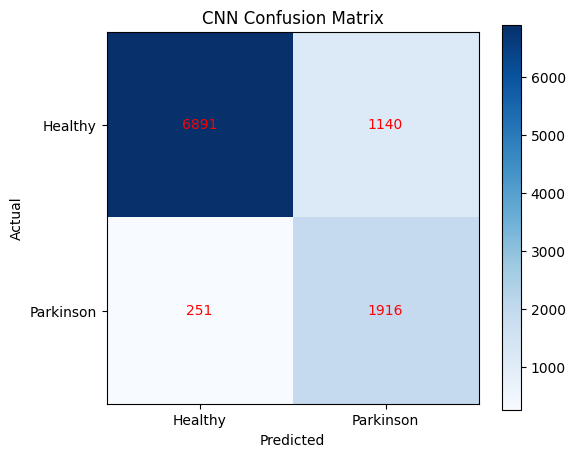

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cnn_preds = model.predict(valid_X)
cnn_pred_classes = np.argmax(cnn_preds, axis=1)
cnn_true_classes = np.argmax(valid_Y, axis=1)

cm = confusion_matrix(cnn_true_classes, cnn_pred_classes)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.colorbar()

classes = ["Healthy", "Parkinson"]
plt.xticks([0,1], classes)
plt.yticks([0,1], classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [30]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/PD_Project/gait_cnn_model.keras")

LSTM

In [31]:
train_X_lstm = train_X.reshape(train_X.shape[0], 400, 19)
valid_X_lstm = valid_X.reshape(valid_X.shape[0], 400, 19)
test_X_lstm  = test_X.reshape(test_X.shape[0], 400, 19)



In [32]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential()
lstm_model.add(LSTM(128, return_sequences=False, input_shape=(400,19)))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(64, activation="relu"))
lstm_model.add(Dense(2, activation="softmax"))
lstm_model.summary()





/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        75,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,162 (328.76 KB)

 Trainable params: 84,162 (328.76 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_history = lstm_model.fit(
    train_X_lstm, train_Y,
    validation_data=(valid_X_lstm, valid_Y),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.7323 - loss: 0.5357 - val_accuracy: 0.8228 - val_loss: 0.3742
Epoch 2/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.7974 - loss: 0.4457 - val_accuracy: 0.8306 - val_loss: 0.3741
Epoch 3/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.8368 - loss: 0.3861 - val_accuracy: 0.8443 - val_loss: 0.3492
Epoch 4/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8625 - loss: 0.3361 - val_accuracy: 0.8416 - val_loss: 0.3525
Epoch 5/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.8833 - loss: 0.2965 - val_accuracy: 0.8295 - val_loss: 0.3886
Epoch 6/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.8892 - loss: 0.2769 - val_accuracy: 0.8355 - val_loss: 0.3682
Epoch 7/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.9011 - loss: 0.2551 - val_accuracy: 0.8419 - val_loss: 0.3475
Epoch 8/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.9056 -

In [34]:
lstm_model.save("/content/drive/MyDrive/PD_Project/gait_lstm_model.keras")
print("LSTM model saved")

LSTM model saved


In [35]:
lstm_model = load_model("/content/drive/MyDrive/PD_Project/gait_lstm_model.keras")

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# LSTM predictions already computed
lstm_preds = lstm_model.predict(valid_X_lstm)

lstm_pred_classes = np.argmax(lstm_preds, axis=1)
lstm_true_classes = np.argmax(valid_Y, axis=1)

lstm_accuracy = accuracy_score(lstm_true_classes, lstm_pred_classes)
lstm_precision = precision_score(lstm_true_classes, lstm_pred_classes)
lstm_recall = recall_score(lstm_true_classes, lstm_pred_classes)
lstm_f1 = f1_score(lstm_true_classes, lstm_pred_classes)

print("LSTM Accuracy:", round(lstm_accuracy, 4))
print("LSTM Precision:", round(lstm_precision, 4))
print("LSTM Recall:", round(lstm_recall, 4))
print("LSTM F1 Score:", round(lstm_f1, 4))


319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
LSTM Accuracy: 0.8409
LSTM Precision: 0.6503
LSTM Recall: 0.5431
LSTM F1 Score: 0.5919


319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


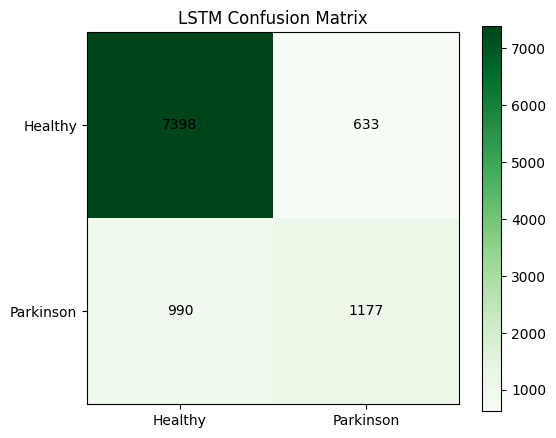

In [37]:
lstm_preds = lstm_model.predict(valid_X_lstm)
lstm_pred_classes = np.argmax(lstm_preds, axis=1)
lstm_true_classes = np.argmax(valid_Y, axis=1)

cm_lstm = confusion_matrix(lstm_true_classes, lstm_pred_classes)

plt.figure(figsize=(6,5))
plt.imshow(cm_lstm, cmap="Greens")
plt.title("LSTM Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], classes)
plt.yticks([0,1], classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_lstm[i, j], ha="center", va="center", color="black")

plt.show()


BiLSTM

In [38]:
from keras.layers import Bidirectional
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from keras import callbacks
bilstm_model = Sequential()
bilstm_model.add(Bidirectional(LSTM(128, return_sequences=False), input_shape=(400,19)))
bilstm_model.add(Dropout(0.5))
bilstm_model.add(Dense(64, activation="relu"))
bilstm_model.add(Dense(2, activation="softmax"))
bilstm_model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 256)            │       151,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,130 (656.76 KB)

 Trainable params: 168,130 (656.76 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

bilstm_history = bilstm_model.fit(
    train_X_lstm, train_Y,
    validation_data=(valid_X_lstm, valid_Y),
    epochs=20,
    batch_size=32,
    verbose=1
)



Epoch 1/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 59s 40ms/step - accuracy: 0.7559 - loss: 0.5003 - val_accuracy: 0.8410 - val_loss: 0.3530
Epoch 2/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.8388 - loss: 0.3692 - val_accuracy: 0.8510 - val_loss: 0.3365
Epoch 3/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 49s 34ms/step - accuracy: 0.8734 - loss: 0.2976 - val_accuracy: 0.8516 - val_loss: 0.3489
Epoch 4/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - accuracy: 0.8876 - loss: 0.2732 - val_accuracy: 0.8710 - val_loss: 0.3483
Epoch 5/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 49s 34ms/step - accuracy: 0.9092 - loss: 0.2268 - val_accuracy: 0.8514 - val_loss: 0.3837
Epoch 6/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - accuracy: 0.9165 - loss: 0.2090 - val_accuracy: 0.8606 - val_loss: 0.3817
Epoch 7/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - accuracy: 0.9252 - loss: 0.1885 - val_accuracy: 0.8312 - val_loss: 0.4652
Epoch 8/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 52s 36ms/step - accuracy: 0.9326 -

In [40]:
from tensorflow.keras.models import load_model
bilstm_model.save("/content/drive/MyDrive/PD_Project/gait_bilstm_model.keras")
print("BiLSTM model saved")

BiLSTM model saved


In [41]:
from tensorflow.keras.models import load_model
bilstm_model = load_model("/content/drive/MyDrive/PD_Project/gait_bilstm_model.keras")

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
# BiLSTM predictions already computed
bilstm_preds = bilstm_model.predict(valid_X_lstm)

bilstm_pred_classes = np.argmax(bilstm_preds, axis=1)
bilstm_true_classes = np.argmax(valid_Y, axis=1)

bilstm_accuracy = accuracy_score(bilstm_true_classes, bilstm_pred_classes)
bilstm_precision = precision_score(bilstm_true_classes, bilstm_pred_classes)
bilstm_recall = recall_score(bilstm_true_classes, bilstm_pred_classes)
bilstm_f1 = f1_score(bilstm_true_classes, bilstm_pred_classes)

print("BiLSTM Accuracy:", round(bilstm_accuracy, 4))
print("BiLSTM Precision:", round(bilstm_precision, 4))
print("BiLSTM Recall:", round(bilstm_recall, 4))
print("BiLSTM F1 Score:", round(bilstm_f1, 4))


319/319 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
BiLSTM Accuracy: 0.8382
BiLSTM Precision: 0.6255
BiLSTM Recall: 0.5944
BiLSTM F1 Score: 0.6096


319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


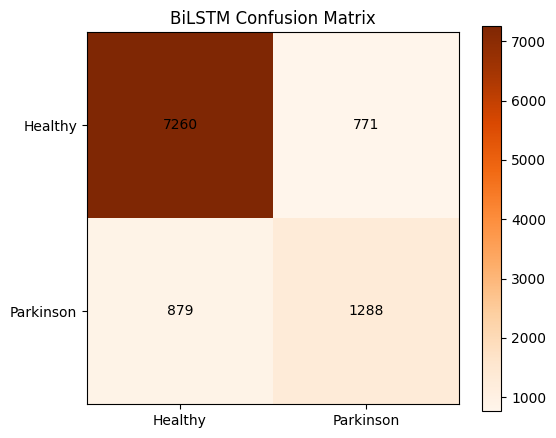

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
bilstm_preds = bilstm_model.predict(valid_X_lstm)
bilstm_pred_classes = np.argmax(bilstm_preds, axis=1)
bilstm_true_classes = np.argmax(valid_Y, axis=1)
classes = ["Healthy", "Parkinson"]

cm_bilstm = confusion_matrix(bilstm_true_classes, bilstm_pred_classes)

plt.figure(figsize=(6,5))
plt.imshow(cm_bilstm, cmap="Oranges")
plt.title("BiLSTM Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], classes)
plt.yticks([0,1], classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_bilstm[i, j], ha="center", va="center", color="black")

plt.show()


CNN-BiLSTM

In [44]:
import numpy as np
import tensorflow as tf
import random
import os

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dropout,
    Reshape, Dense, Bidirectional, LSTM
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


In [45]:
class TemporalAttention(Layer):
    def __init__(self, **kwargs):
        super(TemporalAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )
        super(TemporalAttention, self).build(input_shape)

    def call(self, inputs):
        e = K.tanh(K.dot(inputs, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = inputs * a
        return K.sum(output, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])


In [46]:
# reshape for CNN feature extraction first
train_X_cnn = train_X.reshape(train_X.shape[0], 19, 400, 1)
valid_X_cnn = valid_X.reshape(valid_X.shape[0], 19, 400, 1)
test_X_cnn  = test_X.reshape(test_X.shape[0], 19, 400, 1)


In [47]:
cnn_input = Input(shape=(19, 400, 1))

x = Conv2D(32, 3, padding="same", activation="relu")(cnn_input)
x = MaxPooling2D(pool_size=(1,2))(x)

x = Conv2D(64, 3, padding="same", activation="relu")(x)
x = MaxPooling2D(pool_size=(1,2))(x)
x = Dropout(0.3)(x)

time_steps = x.shape[2]
feature_dim = x.shape[1] * x.shape[3]

x = Reshape((time_steps, feature_dim))(x)

x = Bidirectional(LSTM(128, return_sequences=True))(x)

x = TemporalAttention()(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(2, activation="softmax")(x)

model = Model(cnn_input, output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_58"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 19, 400, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 19, 400, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 19, 200, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 19, 200, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 19, 100, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 19, 100, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 100, 1216)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100, 256)       │     1,377,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ (None, 256)            │           356 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,429,606 (5.45 MB)

 Trainable params: 1,429,606 (5.45 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_X_cnn, train_Y,
    validation_data=(valid_X_cnn, valid_Y),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.8557 - loss: 0.3286 - val_accuracy: 0.8494 - val_loss: 0.3887
Epoch 2/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.9648 - loss: 0.0972 - val_accuracy: 0.8379 - val_loss: 0.5539
Epoch 3/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.9768 - loss: 0.0628 - val_accuracy: 0.8565 - val_loss: 0.5218
Epoch 4/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 51s 35ms/step - accuracy: 0.9814 - loss: 0.0512 - val_accuracy: 0.8504 - val_loss: 0.6375
Epoch 5/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.9830 - loss: 0.0461 - val_accuracy: 0.8424 - val_loss: 0.6315
Epoch 6/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 52s 36ms/step - accuracy: 0.9839 - loss: 0.0415 - val_accuracy: 0.8432 - val_loss: 0.7367
Epoch 7/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 51s 35ms/step - accuracy: 0.9873 - loss: 0.0326 - val_accuracy: 0.8626 - val_loss: 0.7501
Epoch 8/20
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.9863 -

In [49]:
from tensorflow.keras.models import load_model
model.save("/content/drive/MyDrive/PD_Project/gait_cnn_bilstm_attention_model.keras")
print("CNN-BiLSTM model saved")

CNN-BiLSTM model saved


In [50]:
from tensorflow.keras.models import load_model
cnn_bilstm_attention_model = load_model("/content/drive/MyDrive/PD_Project/gait_cnn_bilstm_attention_model.keras", custom_objects={"TemporalAttention": TemporalAttention})

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

preds = model.predict(valid_X_cnn)
pred_classes = preds.argmax(axis=1)
true_classes = valid_Y.argmax(axis=1)

print("Accuracy:", round(accuracy_score(true_classes, pred_classes), 4))
print("Precision:", round(precision_score(true_classes, pred_classes), 4))
print("Recall:", round(recall_score(true_classes, pred_classes), 4))
print("F1 Score:", round(f1_score(true_classes, pred_classes), 4))


319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Accuracy: 0.8729
Precision: 0.6916
Recall: 0.7254
F1 Score: 0.7081


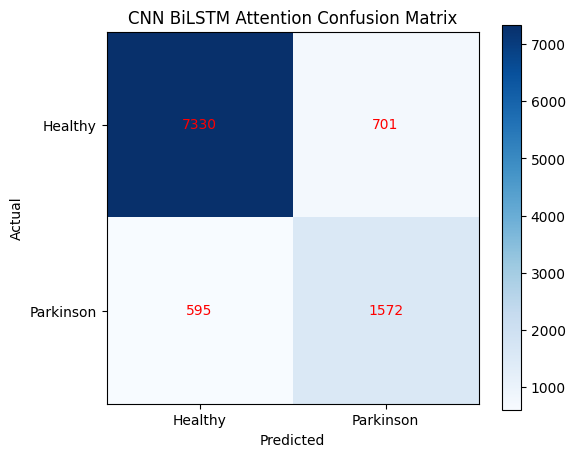

In [52]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks([0,1], ["Healthy", "Parkinson"])
plt.yticks([0,1], ["Healthy", "Parkinson"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", color="red")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN BiLSTM Attention Confusion Matrix")
plt.show()


CNN-LSTM

In [53]:
# reshape for CNN LSTM
train_X_cnnlstm = train_X.reshape(train_X.shape[0], 400, 19, 1, 1)
valid_X_cnnlstm = valid_X.reshape(valid_X.shape[0], 400, 19, 1, 1)
test_X_cnnlstm  = test_X.reshape(test_X.shape[0], 400, 19, 1, 1)

print(train_X_cnnlstm.shape)


(45652, 400, 19, 1, 1)


In [54]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout
from keras.layers import LSTM, Dense, TimeDistributed, Flatten
from keras.optimizers import Adam

cnn_lstm_model = Sequential()

# CNN feature extractor
cnn_lstm_model.add(
    TimeDistributed(
        Conv2D(32, (3,3), activation="relu", padding="same"),
        input_shape=(400, 19, 1, 1)
    )
)
cnn_lstm_model.add(TimeDistributed(MaxPooling2D((2,1))))
cnn_lstm_model.add(TimeDistributed(Dropout(0.3)))

cnn_lstm_model.add(TimeDistributed(Conv2D(64, (3,3), activation="relu", padding="same")))
cnn_lstm_model.add(TimeDistributed(MaxPooling2D((2,1))))
cnn_lstm_model.add(TimeDistributed(Dropout(0.3)))

cnn_lstm_model.add(TimeDistributed(Flatten()))

# LSTM temporal modeling
cnn_lstm_model.add(LSTM(128, return_sequences=False))
cnn_lstm_model.add(Dropout(0.5))

# Classification
cnn_lstm_model.add(Dense(64, activation="relu"))
cnn_lstm_model.add(Dense(2, activation="softmax"))

cnn_lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 400, 19, 1, 32) │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 400, 9, 1, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 400, 9, 1, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 400, 9, 1, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 400, 4, 1, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 400, 4, 1, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 400, 256)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,322 (876.26 KB)

 Trainable params: 224,322 (876.26 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
cnn_lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [56]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

cnn_lstm_history = cnn_lstm_model.fit(
    train_X_cnnlstm,
    train_Y,
    validation_data=(valid_X_cnnlstm, valid_Y),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
2854/2854 ━━━━━━━━━━━━━━━━━━━━ 1844s 566ms/step - accuracy: 0.7334 - loss: 0.5334 - val_accuracy: 0.8489 - val_loss: 0.3568
Epoch 2/20
1689/2854 ━━━━━━━━━━━━━━━━━━━━ 10:20 533ms/step - accuracy: 0.8451 - loss: 0.3651

KeyboardInterrupt: 

In [ ]:
cnn_lstm_model.save("/content/drive/MyDrive/PD_Project/gait_cnn_lstm_model.keras")
print("CNN LSTM model saved")


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

cnn_lstm_preds = cnn_lstm_model.predict(valid_X_cnnlstm)

cnn_lstm_pred_classes = np.argmax(cnn_lstm_preds, axis=1)
cnn_lstm_true_classes = np.argmax(valid_Y, axis=1)

acc = accuracy_score(cnn_lstm_true_classes, cnn_lstm_pred_classes)
prec = precision_score(cnn_lstm_true_classes, cnn_lstm_pred_classes)
rec = recall_score(cnn_lstm_true_classes, cnn_lstm_pred_classes)
f1 = f1_score(cnn_lstm_true_classes, cnn_lstm_pred_classes)

print("CNN LSTM Accuracy:", round(acc,4))
print("CNN LSTM Precision:", round(prec,4))
print("CNN LSTM Recall:", round(rec,4))
print("CNN LSTM F1:", round(f1,4))


In [ ]:
cm = confusion_matrix(cnn_lstm_true_classes, cnn_lstm_pred_classes)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Purples")
plt.title("CNN-LSTM Confusion Matrix")
plt.colorbar()

classes = ["Healthy", "Parkinson"]
plt.xticks([0,1], classes)
plt.yticks([0,1], classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [57]:
#load the test probability scores
preds_gait = model.predict(test_X_cnn)          # shape: (N, 2)
gait_test_probs  = preds_gait[:, 1]             # PD class probability
gait_test_labels = test_Y.argmax(axis=1)        # true labels (0 or 1)

np.save("gait_test_probs.npy",  gait_test_probs)
np.save("gait_test_labels.npy", gait_test_labels)
print("Gait test probs saved:", gait_test_probs.shape)

334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Gait test probs saved: (10677,)
